### Normalizing Flow 

This notebook will experiment with multiple aspects of Normalizing Flow related stuffs like:

1. Generate half-moon distribution - NICE will be used to do it. 
2. Sample from a distribution knowing its pdf.
3. Recentering techique will be applied for sampling process  

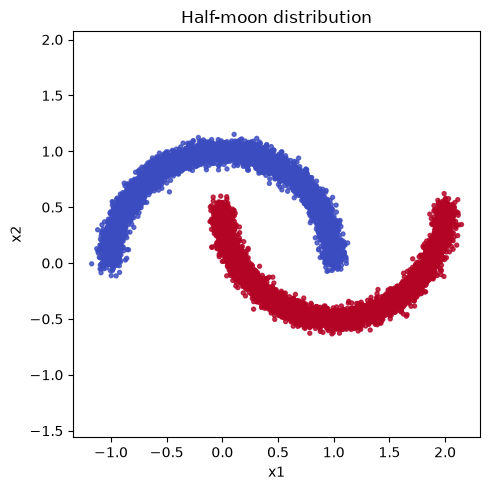

X shape: (10000, 2), y shape: (10000,)


In [12]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

n_samples = 10000
noise = 0.05
X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap="coolwarm", alpha=0.8)
plt.title("Half-moon distribution")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"X shape: {X.shape}, y shape: {y.shape}")

### Recentering

Whiten the data to mean $0$ and covariance $I$ before training NICE:

$$
\tilde{x} = K^{-1}(x - \mu),\qquad \Sigma = KK^\top
$$

We take $K = L$ from the Cholesky factor $\Sigma = LL^\top$. Stats $(\mu, K)$ are estimated once on the full training set and then frozen. To map samples back:

$$
x = \mu + K\,\tilde{x}
$$

mu: [0.50057444 0.24972914]
Sigma:
 [[ 0.75237977 -0.19232314]
 [-0.19232314  0.24610214]]
cov(X_white) ≈
 [[1.00000000e+00 2.64253954e-16]
 [2.64253954e-16 1.00000000e+00]]
mean(X_white): [4.51194637e-16 3.81177312e-15]


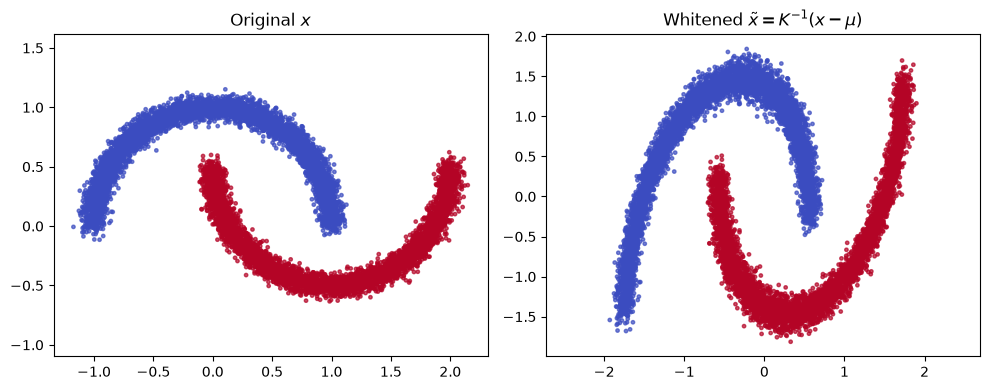

In [13]:
import numpy as np
from numpy.linalg import cholesky, solve

# --- estimate mean & covariance on all training data ---
mu = X.mean(axis=0)
Xc = X - mu
Sigma = (Xc.T @ Xc) / (X.shape[0] - 1)

# K = L with Sigma = L L^T
K = cholesky(Sigma)
K_inv = solve(K, np.eye(K.shape[0]))  # K^{-1}

X_white = (Xc @ K_inv.T)  # equivalent to (K^{-1} (x-mu)^T)^T

print("mu:", mu)
print("Sigma:\n", Sigma)
print("cov(X_white) ≈\n", np.cov(X_white.T))
print("mean(X_white):", X_white.mean(axis=0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=y, s=6, cmap="coolwarm", alpha=0.7)
axes[0].set_title("Original $x$")
axes[0].axis("equal")
axes[1].scatter(X_white[:, 0], X_white[:, 1], c=y, s=6, cmap="coolwarm", alpha=0.7)
axes[1].set_title(r"Whitened $\tilde{x} = K^{-1}(x-\mu)$")
axes[1].axis("equal")
plt.tight_layout()
plt.show()

### Train NICE on half-moon

Train on **whitened** data $\tilde{x}$ from the Recentering section.

Couplings have $\det=1$; learnable diagonal scaling contributes $\sum_i (\log s)_i$:

$$
\mathcal{L}(\theta)
= \mathbb{E}_{\tilde{x}}\Big[\tfrac{1}{2}\|f_\theta(\tilde{x})\|^2 - \sum_i (\log s)_i\Big]
$$

Train so latents look like $\mathcal{N}(0,I)$ while fitting volume via $\log s$.

In [14]:
import runpy
from pathlib import Path

import jax
import jax.numpy as jnp
import optax
from jax import random
from tqdm import trange

# project root on sys.path
_root = Path.cwd() if (Path.cwd() / "libs").is_dir() else Path.cwd().parent
runpy.run_path(str(_root / "setup_path.py"), run_name="__setup_path__")

from libs.nice_scratch import NICE

# --- data / model (whitened) ---
X_train = jnp.asarray(X_white, dtype=jnp.float32)
model = NICE(layer_size=2, no_layers=4, hidden_sizes=(64, 64))

key = random.PRNGKey(0)
key, k_init = random.split(key)
variables = model.init(k_init, X_train[:8])
params = variables["params"]

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

def loss_fn(params, batch):
    z, log_det = model.apply({"params": params}, batch)
    # log_det = sum(log s); same for every sample in the batch
    return 0.5 * jnp.mean(jnp.sum(z**2, axis=-1)) - log_det

@jax.jit
def train_step(params, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, batch)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# --- 2000 epochs ---
n_epochs = 2000
batch_size = 128
losses = []

for epoch in trange(n_epochs, desc="NICE train"):
    key, k_perm = random.split(key)
    perm = random.permutation(k_perm, X_train.shape[0])
    X_shuf = X_train[perm]

    batch_losses = []
    # training with batch-SGD
    for start in range(0, X_train.shape[0], batch_size):
        batch = X_shuf[start : start + batch_size]
        params, opt_state, loss = train_step(params, opt_state, batch)
        batch_losses.append(loss)

    epoch_loss = float(jnp.mean(jnp.stack(batch_losses)))
    losses.append(epoch_loss)
    if epoch % 100 == 0:
        print("loss after {} epoch = {}".format(epoch, epoch_loss))

print(f"final loss: {losses[-1]:.4f} (start {losses[0]:.4f})")

NICE 

loss after 0 epoch = 0.9812033176422119


NICE 

loss after 100 epoch = -0.25377780199050903


NICE 

...

loss after 1800 epoch = -0.3703894019126892


NICE 

loss after 1900 epoch = -0.3817876875400543


NICE 

final loss: -0.3925 (start 0.9812)


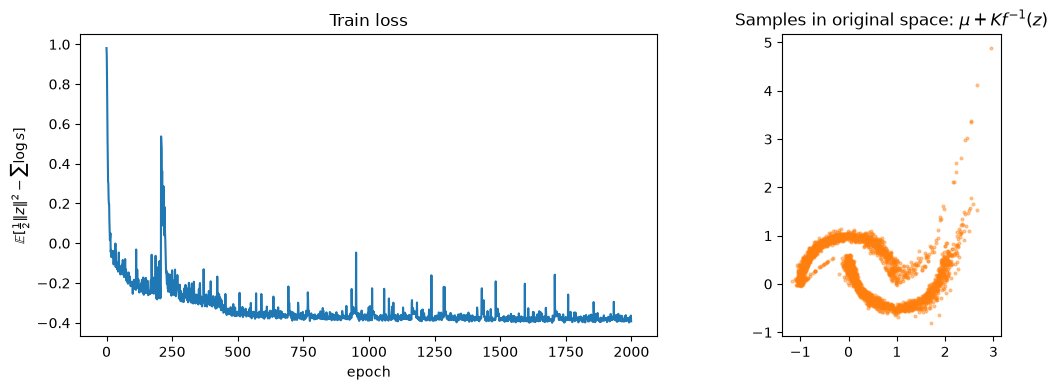

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel(r"$\mathbb{E}[\frac{1}{2}\|z\|^2 - \sum \log s]$")

key, k_samp = random.split(key)
z_prior = random.normal(k_samp, (3000, 2))
x_white_gen, _ = model.apply({"params": params}, z_prior, reverse=True)

# invert recentering: x = mu + K @ x_tilde
x_gen = mu + np.asarray(x_white_gen) @ K.T

axes[1].scatter(x_gen[:, 0], x_gen[:, 1], s=4, alpha=0.4, c="tab:orange")
axes[1].set_title(r"Samples in original space: $\mu + K f^{-1}(z)$")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()